# **Perineuronal net morphology (PNN) morphology analysis notebook**

# <mark> TODO:
- <mark> continue mock versioning
- <mark> decide which of the below steps can come from infer-subc directly
- <mark> implement adjustments for uint8 local thresholding

## **Versioning:**
- **V1.1**: 12/11/2025 SR updates based on feedback from HSO
    - Load file (no change)
    - Segment PNN from WFA channel
        - Thresholding: update to add local and automated thresholding methods
    - Skeletonize PNN segmentation (no change)
    - Quantify PNN morphology & marker intensity:
        - Adding per PNN object and per PNN morphology quantification (skimage regionprops) and per object/PNN intensity quant of some additional channels (if they are the same resolution)

- **V1.0**: 10/28/2025 SR creates first draft with the following goals
    - Load file
        - list files of a specific type in path
        - read files (BioIO)
    - Segment PNN from WFA channel
        - Rescale intensities: min value = 0, max value = 1
        - Background subtraction: None
        - Denoising: None
        - Smoothing: gaussian = 2, median = 8
        - Thresholding: manual (low pass filter)
        - Clean-up: remove small objects (<10, 3D), fill small holes (none)
        - Instance segmentation: connectivity-based
    - Skeletonize PNN segmentation
        - Create skeleton object (skimage & skan)
        - Refine skeleton: remove small end-point branches (<1 um)
    - Quantify PNN morphology & marker intensity:
        - Intensity within entire PNN (segmented area, not per object)
        - Count and skeleton morphology metrics (from skan)

## **Set up instructions:**
1. Install the following packages into your computer's base environment or into a new Python environment. Execute the following code line by line in your computers terminal (e.g., Command Prompt for Windows)
    - If creating a conda environment for this project to manage your packages
        - Install [Anaconda](https://www.anaconda.com/download) and add to PATH variables during setup if running on a Windows computer.
        - Run the following commands in your terminal:
            > ```Python
            > conda create -n PNN-morpho python=3.13
            > y
            > conda activate PNN-morpho
            ```
        - Continue with the non-conda environment instructions below
    - If you are installing packages into your computer's based environment
        - Run the following commands in your terminal:
            > ```python
            > pip install python==3.13
            > ```
    - After creating a conda environment and/or install python
        - Run the following commands in your terminal:
            > ```Python
            > pip install ipython ipykernel
            > pip install bioio bioio-ome-tiff bioio-tifffile
            > pip install napari[all]
            > pip intall dask-image # only is using dask image reading
            > pip install skan
            > pip install napari-ome-zarr # only if using zarr formatting
            > pip install bioio-lif # reading the raw .lif files
            > ```
2. Download [Visual Studio Code](https://code.visualstudio.com/Download) 
3. Open this file in VSCode
4. Click on `Select Kernel` in the top right; choose `Python Environment...` and either `PNN-morpho` or `base` from the list of options based on your choice above.

## **Imports:**
Below, the packages/functions necessary for this analysis are imported.

In [45]:
# IMPORTS
from pathlib import Path
from typing import Tuple, Any, Union
import time

from bioio import BioImage
from bioio.writers import OmeTiffWriter
from tifffile import imwrite

import napari

# from dask_image.imread import imread
import numpy as np
import skimage
import skan
import matplotlib.pyplot as plt
from scipy import stats
import infer_subc

import sys
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
pd.set_option('display.max_columns', None)

----------

## **Testing Analysis Settings (on a single image)**

### **1. Read file and metadata**

#### **1A. List files in path**

Specify the following information:
- `file_path`: string of the file path where the input images are located
- `file_type`: string of the input file type (e.g., ".tif") 

Then run the cell below to read in the list of file of that type found in the location specified.

In [2]:
### USER INPUTS ###
file_path = "/users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/cKO"  # OPTIONS:  WT" cKO"
file_type = ".tif"



### PROCESSING - no edits below ###
# open a Napari viewer window to visualize images & processing steps
viewer = napari.Viewer()

# create sorted list of files in directory with specified file type
file_list = sorted(Path(file_path).glob(f"*{file_type}"))

# print list of files with associated index number for selection below
pd.set_option('display.max_colwidth', None)
pd.DataFrame({"Image Name":file_list})

/nas/longleaf/home/srhoads/.conda/envs/PNN-morpho/lib/python3.12/site-packages/npe2/manifest/_npe1_adapter.py:87: UserWarning: Error importing contributions for first-generation napari plugin 'napari-aicsimageio': '_TIFF' object has no attribute 'RESUNIT'
  self._load_contributions()


,Image Name
0,/users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/cKO/382_2_Cell_One_L3_SSCX_WFA_decon_0.tif
1,/users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/cKO/382_2_Cell_Three_L3_SSCX_WFA_decon_0.tif
2,/users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/cKO/382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif


Specify the following information:
- `file_index`: the index of the image you would like to look at in the analysis below. The index value is found to the left of the file paths listed in the table above.

Then run the cell below to read in and view some of its metadata.

#### **1B. Select file of interest for testing**

In [3]:
### USER INPUTS ###
file_index = 2  # change this number to select a different file from the list above



### PROCESSING - no edits below ###
# read in file
raw_file = BioImage(str(file_list[file_index]))
raw_img = raw_file.data
metadata = raw_file.standard_metadata

# save relevant metadata information as objects for use later
voxel_size_ZYX = (raw_file.physical_pixel_sizes.Z, raw_file.physical_pixel_sizes.Y, raw_file.physical_pixel_sizes.X)

# print relevant info about the image
print("File shape:", raw_file.shape)
print("Dimensions:", raw_file.dims)
print("Image channels:", raw_file.channel_names)
print("Voxel size:", raw_file.physical_pixel_sizes)


### ALTERNATIVE - if .lif file/metadata desired ###
# # read in .lif file
# lif_path = r"W:\Baldwin Lab\Hayli Spence-Osorio\PNN Project Data\Pair 4\Metadata\250429_HSO_PNN_Pair_4_Day_1.lif"
# lif_imgs = BioImage(lif_path)

# # extract raw image data and metadata
# lif_img_raw = lif_imgs.data
# lif_metadata = lif_imgs.metadata

# # view image in napari
# viewer.add_image(lif_img_raw, scale=voxel_size_ZYX, name="Deconvolved PNN image")

#####################################################################
### DEPRICATED ###
# # alternative read approach using dask array
# # the dask array approach before is formatted to utilize a series of tif images that separate channels, z's, time, etc.. 
# # Zarr formatting may still be the best approach for single files
# stack = imread(str(file_list[file_index]))
# napari.imshow(stack, multiscale=False)

Attempted file (/users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/cKO/382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/cKO/382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 6


File shape: (1, 1, 71, 1992, 1992)
Dimensions: <Dimensions [T: 1, C: 1, Z: 71, Y: 1992, X: 1992]>
Image channels: [np.str_('Channel:0:0')]
Voxel size: PhysicalPixelSizes(Z=0.072295, Y=0.014597000527542049, X=0.014597000527542049)


#### **4C. [*optional*] Select small subregion in image to speedup processing below**

Specify the following:
- `use_small_region`: True/False to indicate if you would like to only process a smaller portion of the image (memory saving step) in the steps below, or not. *Note: if you would like to change which chunk of the image you are selecting, you can adjust the coordinates being selected within the np.squeeze()[] function's square brackets.* 

Then run the cell below to select the small portion of your image, or the entire image. The output can be visualized in the Napari window.

In [4]:
### USER INPUTS ###
use_small_region = True  # set to True to use a small region of the image for testing purposes 


### PROCESSING - no edits below ###
# select small region or full image for testing analysis
if use_small_region:
    test_img = np.squeeze(raw_img)[30:45, 800:1250, 600:1050]
else:
    test_img = np.squeeze(raw_img)

# visualize image in napari
viewer.layers.clear()
viewer.add_image(test_img, scale=voxel_size_ZYX, name="Deconvolved PNN image")
print("The test image has been added to the Napari viewer.")

The test image has been added to the Napari viewer.


### **2. Segment PNN**

#### **2A. Rescale intensity values**


No user input is required.

The cell below rescales the intensity values per image so the max value is always 1 and the minimum value is always. This should help normalize the segmentation outcomes across images if the value ranges vary by image.

<mark> function?

In [5]:
### PROCESSING - no edits below ###
# calculate min/max values
strech_min = test_img.min()
strech_max = test_img.max()

# rescale image
rescale = (test_img - strech_min + 1e-8) / (strech_max - strech_min + 1e-8)

#### ~~**2A. Background subtraction**~~ <mark> **NOT USED AS IT TAKES A TON OF TIME TO PROCESS** - will try without this first </mark>

~~[`Rolling ball background subtraction`](https://scikit-image.org/docs/0.25.x/auto_examples/segmentation/plot_rolling_ball.html) can be used to remove non-uniform background from images before segmentaiton or intensity measurements. In this process the amount of background per pixel/voxel is calculated from a region about the image (here defined as the radius). The radius (in voxels) can be adjusted to modify the effects of the rolling ball algorithm; it should be larger than the largest object/structure of interest in your image.~~



In [6]:
# ### USER INPUT ###
# bg_radius = 50

# # calculate background per pixel using the rolling ball method
# bg = skimage.restoration.rolling_ball(test_img, radius=bg_radius)
# bg_subtract = test_img - bg

# # visualize output
# viewer.add_image(bg_subtract, scale=voxel_size_ZYX, name="Background subtracted")

#### ~~**2A. Denoising**~~ <mark> **NOT USED AS IT TAKES A TON OF TIME TO PROCESS** - will try without this first </mark>

~~There is quite a bit of speckley noise in your image that is making segmentation of the PNN intensity more difficult. Below, [`skimage.restoration`](https://scikit-image.org/docs/0.25.x/api/skimage.restoration.html#skimage.restoration.denoise_bilateral) module is used to denoise the image.~~

In [7]:
# denoised = skimage.restoration.denoise_nl_means(test_img, patch_size=50, patch_distance=100)

# viewer.add_image(denoised, scale=voxel_size_ZYX, name="Denoised")

#### **2B. Smoothing**

[`Gaussian`](https://scikit-image.org/docs/0.25.x/api/skimage.filters.html#skimage.filters.gaussian) and [`median`](https://scikit-image.org/docs/0.25.x/api/skimage.filters.rank.html#skimage.filters.rank.median) smoothing filters are commonly used to smooth images and reduce certain types of noise, liek the high salt and pepper noise I think is present in your WFA stained images. The filters smooth the image different ways and are commonly used in combination. I've included both options here with sigma/size filter values that can be used to adjust how much smoothing occurs (large values = more smoothing).

Specify the following:
- `gaus_sigma`: the sigma value used for gaussian smoothing. The higher the number, the more the image is smoothed
- `med_size`: the size value used for the median smoothing filter. The higher the number, the more the image is smoothed

Then run the cell below to apply the smoothing filters. The result can be visualized in the Napari window.

<mark> function?

In [8]:
### USER INPUT ###
gaus_sigma = 2
med_size = 8



### PROCESSING - no edits below ###
# applying smoothing filters
if gaus_sigma:
    smoothed = skimage.filters.gaussian(test_img, sigma=gaus_sigma)
else:
    smoothed = test_img

if med_size:
    fp = skimage.morphology.footprint_rectangle((round(med_size*(voxel_size_ZYX[0]/float(np.max(voxel_size_ZYX)))), 
                                                 round(med_size*(voxel_size_ZYX[1]/float(np.max(voxel_size_ZYX)))), 
                                                 round(med_size*(voxel_size_ZYX[2]/float(np.max(voxel_size_ZYX))))))
    smoothed = skimage.filters.median(smoothed, footprint=fp)

# visualize outputs
viewer.add_image(smoothed, scale=voxel_size_ZYX, name=f"Smoothed: gaus={gaus_sigma}, med={med_size}")

<Image layer 'Smoothed: gaus=2, med=8' at 0x7fe6ba131520>

#### **2C. Thresholding** (multiple options below; choose 1)

There any many types of thresholding methods available in Python. The simplest form is to apply a manual threshold cutoff value to the image (all pixels/voxels with this intensity value and above will be included in the segmentation). Alternatively, the [`skimage`](https://scikit-image.org/docs/stable/api/skimage.filters.html) package has many mathematical approaches to calculate the approate threshold value based on the intensity values in the image within its `threshold` module. These automated threshold can help to adjust segmentation outcomes based on image-to-image variations. 

Both manual and automated thresholding approaches can be applied to the entire image (globally). Automated thresholds can also be applied in a local or adaptive fashion where a small local region surround each voxel area used to set a specific threshold value per voxel. Local thresholding can help to adjust the segmentation outcomes within an image if there are intensity or background variations in different regions.

<ins>**Approach 1:**</ins> Manual, global thresholding

In this approach, a cutoff value, representing the minimum intensity value to include as part of the segmentation, is specified by the user. Any voxels with an intensity value less than the cutoff will be excluded from the semantic segmentation.

Specify the following:
- `manual_cutoff`: The minimum intensity value you wish to include in your segmentation

Then run the cell below to apply the cutoff value to your entire image. The resulting segmentation is output into the Napari window.

In [9]:
### USER INPUT ###
manual_cutoff = 0.045


### PROCESSING - no edits below ###
# select everything above threshold value for segmentation
seg = smoothed >= manual_cutoff

# visualize segmentation
viewer.add_image(seg, scale=voxel_size_ZYX, name=f"Segmentation: thresh={manual_cutoff}", blending="additive", opacity=0.4, colormap='magenta')

<Image layer 'Segmentation: thresh=0.045' at 0x7fe6b8e88890>

<ins>**Approach 2:**</ins> Automated thresholding

In this approach, the threshold cutoff value per image is calculated based on the range of intensity values within that image. The common automated thresholding approaches included in the ['skimage'](https://scikit-image.org/docs/stable/api/skimage.filters.html) package can be applied here.

Specify the following:
- `automated_method`: the name of the automated thresholding method. Options include: 'otsu', 'li', 'yen', 'isodata', 'triangle', 'minimum', 'mean'. You can read more about each method here: ['skimage.filters` documentation](https://scikit-image.org/docs/0.23.x/api/skimage.filters.html#module-skimage.filters) and [thresholding examples](https://scikit-image.org/docs/0.23.x/auto_examples/segmentation/plot_thresholding.html)

Then run the cell below to apply your chosen thresholding approach to the entire image. The resulting semgnetation is output in the Napari window.

In [10]:
### USER INPUT ###
threshold_method = 'multiotsu'      # OPTIONS: 'otsu', 'li', 'yen', 'isodata', 'triangle', 'minimum', 'mean', 'multiotsu'
adjust = 0.55                      # OPTIONS: 1 = no threshold adjustment, <1 = more stuff selected, >1 = less stuff selected
multiotsu_middle_to = 'background'  # OPTIONS: 'foreground', 'background'


### PROCESSING - no edits below ###
# Apply automated threshold based on selected method
if threshold_method == 'otsu':
    thresh_value = skimage.filters.threshold_otsu(smoothed)
elif threshold_method == 'multiotsu':
    thresholds = skimage.filters.threshold_multiotsu(smoothed, classes=3)
    if multiotsu_middle_to == 'foreground':
        thresh_value = thresholds[0]  # select the second highest threshold
    elif multiotsu_middle_to == 'background':
        thresh_value = thresholds[1]   # select the lowest threshold
    else:
        raise ValueError(f"Unrecognized multiotsu middle to option: {multiotsu_middle_to}")
elif threshold_method == 'li':
    thresh_value = skimage.filters.threshold_li(smoothed)
elif threshold_method == 'yen':
    thresh_value = skimage.filters.threshold_yen(smoothed)
elif threshold_method == 'isodata':
    thresh_value = skimage.filters.threshold_isodata(smoothed)
elif threshold_method == 'triangle':
    thresh_value = skimage.filters.threshold_triangle(smoothed)
elif threshold_method == 'minimum':
    thresh_value = skimage.filters.threshold_minimum(smoothed)
elif threshold_method == 'mean':
    thresh_value = skimage.filters.threshold_mean(smoothed)
else:
    raise ValueError(f"Unrecognized threshold method: {threshold_method}")

# Apply threshold with optional adjustment
seg_auto = smoothed >= thresh_value*adjust

# Print the calculated threshold value for reference
print(f"Calculated threshold value using {threshold_method}: {thresh_value*adjust}")

# Visualize segmentation
viewer.add_image(seg_auto, scale=voxel_size_ZYX, name=f"Auto seg: {threshold_method} (thresh={thresh_value*adjust})", blending="additive", opacity=0.4, colormap='green')


# ### FOR TESTING ALL THE METHODS ###
# ### Compare multiple automated threshold methods ###
# # the following script can be used to visualize the different thresholding methods available in skimage
# methods = ['otsu', 'li', 'yen', 'isodata', 'triangle', 'minimum', 'mean', 'multiotsu']
# multiotsu_middle = 'foreground'  # OPTIONS: 'foreground', 'background'

# for method in methods:
#     if method == 'otsu':
#             thresh_val = skimage.filters.threshold_otsu(smoothed)
#     elif method == 'multiotsu':
#         thresholds = skimage.filters.threshold_multiotsu(smoothed, classes=3)
#         if multiotsu_middle == 'foreground':
#             thresh_val = thresholds[0]  # select the second highest threshold
#         elif multiotsu_middle == 'background':
#             thresh_val = thresholds[1]   # select the lowest threshold
#         else:
#             raise ValueError(f"Unrecognized multiotsu middle to option: {multiotsu_middle}")
#     elif method == 'li':
#         thresh_val = skimage.filters.threshold_li(smoothed)
#     elif method == 'yen':
#         thresh_val = skimage.filters.threshold_yen(smoothed)
#     elif method == 'isodata':
#         thresh_val = skimage.filters.threshold_isodata(smoothed)
#     elif method == 'triangle':
#         thresh_val = skimage.filters.threshold_triangle(smoothed)
#     elif method == 'minimum':
#         thresh_val = skimage.filters.threshold_minimum(smoothed)
#     elif method == 'mean':
#         thresh_val = skimage.filters.threshold_mean(smoothed)
#     else:
#         raise ValueError(f"Unrecognized threshold method: {method}")
    
#     seg_temp = smoothed >= thresh_val*adjust
#     print(f"{method}: threshold = {thresh_val*adjust}")
#     viewer.add_image(seg_temp, scale=voxel_size_ZYX, name=f"{method} ({thresh_val*adjust})", blending="additive", opacity=0.4, colormap='green')

Calculated threshold value using multiotsu: 0.02543492245655563


<Image layer 'Auto seg: multiotsu (thresh=0.02543492245655563)' at 0x7fe6c5fc7bc0>

<ins>**Approach 3:**</ins> Local, automated thresholding 

Above, the threshold was applied globally (to the whole image). Below, we will apply the threshold locally. This determines the threshold value for each pixel/voxel in the image based on the intensity values in a local region around it. The region size and be modified as needed to adjust the thresholding outcomes. The approach could improve segmentation in areas where the intensity range or amount of background varies across different regions within the same image.

*Note: <ins>this approach is MUCH SLOWER</ins> for each image as it has to calculate the threshold cutoff for each voxel separately.*

In [11]:
smoothed.max()

np.float64(0.18567677008403277)

In [12]:
# rescale and convert to 8-bit for local thresholding
max_val = smoothed.max()
smoothed_8bit = np.round((smoothed / max_val)*255).astype(np.uint8)

In [13]:
smoothed_8bit_downscaled = (smoothed_8bit // 2).astype(np.uint8)

np.unique(smoothed_8bit_downscaled)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 124, 125, 127], dtype=uint8)

In [14]:
### USER INPUT ###
# determine the method to use for local thresholding
local_method = 'otsu'       # OPTIONS: 'gaussian', 'mean', 'median', 'otsu', 'li'
local_size = 71            # must be odd; large sizes (takes MORE time) for larger structures, small sizes for smaller structures

# Some methodsrelevant parameters
guassian_sigma_local = 40    # only used if local_method is 'gaussian'


### PROCESSING - no edits below ###
# Calculate global automated threshold value
if local_method == 'otsu':
    # create footprint for local region
    footprint = skimage.morphology.ball(local_size)
    local_otsu_threshold = skimage.filters.rank.otsu(smoothed_8bit_downscaled, footprint)
    seg_local_auto = smoothed_8bit_downscaled > local_otsu_threshold
elif local_method == 'mean':
    local_mean_threshold = skimage.filters.threshold_local(smoothed_8bit, block_size=local_size, method='mean')
    seg_local_auto = smoothed_8bit >= local_mean_threshold
### MEDIAN LOCAL THRESHOLD NOT WORKING ###
# elif local_method == 'median':
#     local_median_threshold = skimage.filters.threshold_local(smoothed, block_size=local_size, offset=0.1, method='median')
#     seg_local_auto = smoothed >= local_median_threshold
elif local_method == 'gaussian':
    local_gaussian_threshold = skimage.filters.threshold_local(smoothed_8bit, block_size=local_size, method='gaussian', param=guassian_sigma_local)
    seg_local_auto = smoothed_8bit >= local_gaussian_threshold
### NOT TESTED YET ###
# elif local_method in ['li', 'yen']:
#     if local_method == 'li':
#         def thresh_method(neighborhood):
#             funct = skimage.filters.threshold_li(neighborhood)
#             return funct
#     elif local_method == 'yen':
#         def thresh_method(neighborhood):
#             funct = skimage.filters.threshold_yen(neighborhood)
#             return funct
#     elif local_method == 'isodata':
#         def thresh_method(neighborhood):
#             funct = skimage.filters.threshold_isodata(neighborhood)
#             return funct
#     elif local_method == 'triangle':
#         def thresh_method(neighborhood):
#             funct = skimage.filters.threshold_triangle(neighborhood)
#             return funct
#     elif local_method == 'minimum':
#         def thresh_method(neighborhood):
#             funct = skimage.filters.threshold_minimum(neighborhood)
#             return funct
    
#     local_thresholds = skimage.filters.threshold_local(smoothed, block_size=local_size, method='generic', param=thresh_method)
#     seg_local_auto = smoothed >= local_thresholds
else:
    raise ValueError(f"Unrecognized local threshold method: {local_method}")

viewer.add_image(seg_local_auto, scale=voxel_size_ZYX, name=f"Local {local_method.capitalize()} segmentation", blending="additive", opacity=0.4, colormap='cyan')

<Image layer 'Local Otsu segmentation' at 0x7fe6b3c7c6e0>

In [ ]:
### FOR REFERENCE - this works to process local otsu ###
# local_size = 100      ## For [15,450,450] sized image: size=100 -> ~9mins (pretty good outcome); size=11 much faster (created too many smaller objs); size=50 --> 2 mins, 3 sec (similar outcome as manual seg)

# smoothed_uint8 = (smoothed / smoothed.max() * 255).astype(np.uint8)

# footprint = skimage.morphology.ball(local_size)

# local_otsu_threshold = skimage.filters.rank.otsu(smoothed_uint8, footprint)
# binary_local_otsu = smoothed_uint8 > local_otsu_threshold

# viewer.add_image(smoothed_uint8, scale=voxel_size_ZYX, name=f"uint8 smoothed image")
# viewer.add_image(local_otsu_threshold, scale=voxel_size_ZYX, name=f"Local Otsu threshold (radius={local_size})")
# viewer.add_image(binary_local_otsu, scale=voxel_size_ZYX, name=f"Local Otsu segmentation (radius={local_size})", blending="additive", opacity=0.4, colormap='cyan')

#### **2D. Clean-up segmentation**

Segmentations can have errors due to imperfections in the thresholding output. Two different refining setups have been added below: removing small objects and filling small holes.

#### Remove small objects:

In [15]:
### USER INPUTS ###
obj_min_diameter = 10
obj_method = '3D' # OPTIONS: 'slices' or '3D'
seg = seg_local_auto  # choose which segmentation to use for object filtering; OPTIONS: seg, seg_auto, seg_local_auto


### PROCESSING - no edits below ###
# filter objects based on size
if obj_method == 'slices':
    filtered = np.zeros_like(seg)
    for z in range(seg.shape[0]):
        input = seg[z,:,:]
        seg_size_filter = skimage.morphology.remove_small_objects(input, min_size=obj_min_diameter**2)
        input = np.expand_dims(seg_size_filter, axis=0)
        filtered[z,:,:] = input
elif obj_method == '3D':
    filtered = skimage.morphology.remove_small_objects(seg, min_size=obj_min_diameter**3)
else:
    SyntaxError("Unrecognized method chosen. Options include: 'slices' or '3D'.")

# visualize
viewer.add_image(filtered, scale=voxel_size_ZYX, name=f"Filter obj: method={obj_method}, obj={obj_min_diameter}", blending="additive", opacity=0.4, colormap='cyan')

/tmp/ipykernel_3797283/2631943094.py:17: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  filtered = skimage.morphology.remove_small_objects(seg, min_size=obj_min_diameter**3)


<Image layer 'Filter obj: method=3D, obj=10' at 0x7fe6b9e76b40>

#### Fill small holes

In [16]:
### USER INPUTS ###
small_hole_diameter_max = 0
hole_method = 'slices' # OPTIONS: 'slices' or '3D'


### PROCESSING - no edits below ###
# fill holes based on size
if hole_method == 'slices':
    filled = np.zeros_like(filtered)
    for z in range(filtered.shape[0]):
        input = filtered[z,:,:]
        seg_fill_holes = skimage.morphology.remove_small_holes(input, small_hole_diameter_max**2, connectivity=8)
        input = np.expand_dims(seg_fill_holes, axis=0)
        filled[z,:,:] = input
elif hole_method == '3D':
    filled = skimage.morphology.remove_small_holes(filtered, small_hole_diameter_max**3, connectivity=26)
else:
    SyntaxError("Unrecognized method chosen. Options include: 'slices' or '3D'.")

# visualize
viewer.add_image(filled, scale=voxel_size_ZYX, name=f"Fill holes: method={hole_method}, hole={small_hole_diameter_max}", blending="additive", opacity=0.4, colormap='cyan')

/tmp/ipykernel_3797283/259024884.py:12: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  seg_fill_holes = skimage.morphology.remove_small_holes(input, small_hole_diameter_max**2, connectivity=8)
/tmp/ipykernel_3797283/259024884.py:12: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  seg_fill_holes = skimage.mor

<Image layer 'Fill holes: method=slices, hole=0' at 0x7fe6b31a9610>

#### **2E. Create instance segmentation**

The instance segmentation will not be used for skeletonization, but will be able to tell us how many separate pieces of the PNN exist.

In [17]:
### PROCESSING - no edits below ###
# create instance seg
instance_seg = skimage.morphology.label(filled)

# visualize output
viewer.add_labels(instance_seg, scale=voxel_size_ZYX, name=f"Instance segmentation", opacity=0.4)

<Labels layer 'Instance segmentation' at 0x7fe6b3221610>

### **3. Skeletonize segmentation**

[Skeletonization](https://scikit-image.org/docs/0.25.x/auto_examples/edges/plot_skeleton.html) is the process by which a 2D or 3D object is narrowed to a pixel-wide representation of the original area/volume. Then, the skeleton is converted into a network graph using the [`skan`](https://skeleton-analysis.org/stable/) package for easier downstream manipulations.

The napari visualization in the next step shows the skeleton branches color coded by length.

#### **3A. Create skeleton & summarize information about each individual branch**

The summary table includes the following information:
- `skeleton_id`: Unique ID for each separate skeleton object (derived from the instance segmentation label ID)
- `branch_id`: Sequential unique ID for each branch/path in the skeleton (0 to n_paths-1)
- `random_branch_id`: Randomly permuted branch ID for visualization purposes
- `node_id_src`: Pixel index ID of the source/starting node of the branch
- `node_id_dst`: Pixel index ID of the destination/ending node of the branch
- `branch_distance`: Total distance along the branch path in physical units (µm), accounting for pixel spacing
- `branch_type`: Classification of the branch topology:
    - 0 = endpoint-to-endpoint (isolated branch)
    - 1 = junction-to-endpoint
    - 2 = junction-to-junction
    - 3 = isolated cycle
- `mean_pixel_value`: Mean intensity value of pixels along the branch path
- `stdev_pixel_value`: Standard deviation of intensity values along the branch path
- `image_coord_src_0`, `image_coord_src_1`, `image_coord_src_2`: Source node coordinates in image space (pixels) for Z, Y, X respectively
- `image_coord_dst_0`, `image_coord_dst_1`, `image_coord_dst_2`: Destination node coordinates in image space (pixels) for Z, Y, X respectively
- `coord_src_0`, `coord_src_1`, `coord_src_2`: Source node coordinates in physical space (µm) for Z, Y, X respectively
- `coord_dst_0`, `coord_dst_1`, `coord_dst_2`: Destination node coordinates in physical space (µm) for Z, Y, X respectively
- `euclidean_distance`: Straight-line (Euclidean) distance between source and destination nodes in physical units (µm)

In [24]:
### PROCESSING - no edits below ###
# create skeleton - developed new function to create skeleton that labels each skeleton object with the unique ID number specified in the instance segmentation output
# it also ensures that all objects have a skeleton representation, even if it is just a punctate object in the center of the organelle object
def _skeletonize_plus(segmentation: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    ''' A function that generates punctate objects for the round organelle objects that lack a skeleton.

    As of 7/7/24 the original `skeletonize()` function from `skimage` labels the voxels of the skeleton with the same label,
    however the label serves no purpose to us as of now. 
    The purpose of this function is to: 

    1) Establish punctate objects in the center of organelle objects that for some reason lack a skeleton object (if necessary)
    * these objects are found to be round/spherical in every case this happens, so a punctate is appropriate
    2) Return a skeleton with float labels (due to skan requiring this) corresponding to its location in the original segmentation 
    3) Return a boolean skeleton for input in computation

    Parameters:
    -----------
    segmentation : np.ndarray
        A 3D numpy array containing the instance segmentation of the organelle objects.
    
    Returns:
    -----------
    lab_skel : np.ndarray
        A 3D numpy array containing the skeleton output where each skeleton object is labeled with the same label as the organelle object it belongs to.
    skeleton : np.ndarray
        A 3D boolean numpy array containing the boolean skeleton of the organelle objects.
    '''

    # This is the raw organelle skeleton, some fixing and relabeling has to be done before we can use the skeleton for computation
    skeleton = skimage.morphology.skeletonize(segmentation.astype(bool)).astype(bool)

    # All of the organelle object labels
    all_lab = set(pd.unique(segmentation.ravel()))

    # Applying the segmentation labels to the skeleton
    lab_skel = (skeleton * segmentation).astype(int)

    # Labels present in the skeleton
    skel_lab = set(pd.unique(lab_skel.ravel()))

    # Checker to see if there are any objects without a skeleton
    if all_lab == skel_lab:
        return lab_skel.astype(int), skeleton
    
    else:
        # gets a list of the missing labels
        mis_lab = all_lab - skel_lab

        for label in mis_lab:
            # list of coordinates of the object's voxels
            coord_list = np.nonzero(segmentation == label)

            # The coordinate closest to the middle of the object (due to rounding)
            av_coord = np.round(np.mean(coord_list,axis = 1)).astype(int)

            #checker and result
            if segmentation[tuple(av_coord)] == label:
                lab_skel[tuple(av_coord)] = label
            else:
                print("Apperently the centermost point is not in the object???? :(")
                break
        
        return lab_skel.astype(int), skeleton

# apply new function to create skeleton from the instance segmentation
labeled_skel, skeleton = _skeletonize_plus(instance_seg)

# convert to network graph based  labeled skeleton object
skel_g = skan.Skeleton(labeled_skel, spacing=voxel_size_ZYX, value_is_height=False)

# visualize output
viewer.layers.clear()
viewer.add_image(smoothed, scale=voxel_size_ZYX, name=f"Smoothed Input")
viewer.add_image(filled, scale=voxel_size_ZYX, name=f"Segmentation", blending="additive", opacity=0.3)
viewer.add_labels(instance_seg, scale=voxel_size_ZYX, name=f"Instance segmentation", blending="additive", opacity=0.8)

all_paths = [skel_g.path_coordinates(i) for i in range(skel_g.n_paths)]
paths_table = skan.summarize(skel_g, separator='_')
paths_table.insert(1, 'branch_id', np.arange(skel_g.n_paths))
paths_table.insert(2, 'random_branch_id', np.random.default_rng().permutation(skel_g.n_paths))

# replace skeleton_id with the ID of the organelle object from which the skeleton branch originated
if not np.any(skel_g.path_stdev()):
    # checker to see if all path points and nodes come from the same object
    paths_table['skeleton_id'] = skel_g.path_means().astype(int)
else:
    raise ValueError("at least one branch came from different organelle objects")

# calculate the degree of connectivity for each branch end point
endpoints_src = skel_g.paths.indices[skel_g.paths.indptr[:-1]]
endpoints_dst = skel_g.paths.indices[skel_g.paths.indptr[1:] - 1]

deg_src = skel_g.degrees[endpoints_src]
deg_dst = skel_g.degrees[endpoints_dst]
paths_table['deg_src'] = deg_src
paths_table['deg_dst'] = deg_dst

# view skeleton and paths table
viewer.add_shapes(all_paths, shape_type='path', properties=paths_table, edge_width=1, edge_color='skeleton_id', edge_colormap='hsv', scale=voxel_size_ZYX, opacity=1, name="Skeleton")
paths_table.set_index(['skeleton_id', 'branch_id']).sort_index()

random_branch_id  node_id_src  node_id_dst  \
skeleton_id branch_id                                               
1           87                      131          617         5015   
2           22                      368          195         1369   
            24                      193          223         2998   
            89                       56          698         1077   
            90                      427          698          703   
...                                 ...          ...          ...   
28          529                      29         4860         4920   
            535                      90         4920         5945   
29          481                      96         4258         5120   
            543                      69         5069         5120   
            546                     417         5120         5759   

                       branch_distance  branch_type  mean_pixel_value  \
skeleton_id branch_id                                                   
1           87                0.833136            0               1.0   
2           22                0.722780            1               2.0   
            24                0.739842            1               2.0   
            89                0.139619            2               2.0   
            90                0.070481            1               2.0   
...                                ...          ...               ...   
28          529               0.392079            2              28.0   
            535               0.316589            1              28.0   
29          481               0.292672            1              29.0   
            543               0.714714            1              29.0   
            546               0.336463            1              29.0   

                       stdev_pixel_value  image_coord_src_0  \
skeleton_id branch_id                                         
1           87                       0.0                  2   
2           22                       0.0                  1   
            24                       0.0                  1   
            89                       0.0                  2   
            90                       0.0                  2   
...                                  ...                ...   
28          529                      0.0                 12   
            535                      0.0                 12   
29          481                      0.0                 12   
            543                      0.0                 13   
            546                      0.0                 13   

                       image_coord_src_1  image_coord_src_2  \
skeleton_id branch_id                                         
1           87                         3                 43   
2           22                        22                 31   
            24                        33                 79   
            89                        53                 62   
            90                        53                 62   
...                                  ...                ...   
28          529                      398                256   
            535                      415                257   
29          481                      151                 82   
            543                      111                 78   
            546                      138                 90   

                       image_coord_dst_0  image_coord_dst_1  \
skeleton_id branch_id                                         
1           87                        13                  1   
2           22                         4                 35   
            24                        10                 23   
            89                         3                 48   
            90                         2                 55   
...                                  ...                ...   
28          529                

#### **3B. Refine skeleton**
Based on measures calculated by the `skan` package, the skeleton can be refined.

Here, I've chosen to refine the skeleton by removing the shortest branches, but any of the skeleton metrics included in the table below could be used to refine the skeleton.

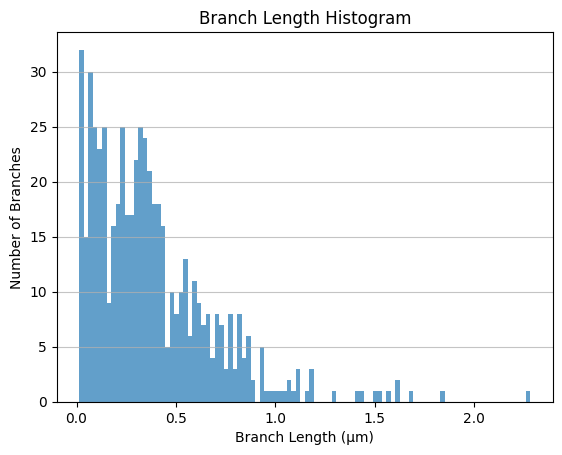

In [25]:
### PROCESSING - no edits below ###
# plot the histogram of branch lengths using plt.hist from matplotlib package
b_len = paths_table['branch_distance']
possible_range = (b_len.min(), b_len.max())
num_bins = round(possible_range[1]-possible_range[0])

plt.hist(paths_table['branch_distance'], bins=num_bins*50, range=possible_range, density=False, alpha=0.7)
plt.title('Branch Length Histogram')
plt.xlabel('Branch Length (µm)')
plt.ylabel('Number of Branches')
plt.grid(axis='y', alpha=0.75)
plt.show()

Using the histogram above and napari visualization, choose the minimum branch length you want to keep within your skeleton object

In [26]:
### USER INPUT ###
min_branch_len = 0.3


### PROCESSING - no edits below ###
# select only branches that have end points
endpoint_indices = paths_table.index[(paths_table['deg_src'] == 1) | (paths_table['deg_dst'] == 1)]
print(f"Number of endpoint branches: {len(endpoint_indices)}")

# select branches that are the min size or below
short_paths_indices = paths_table.index[paths_table['branch_distance'] < min_branch_len]
print(f"Number of branches shorter than {min_branch_len} µm: {len(short_paths_indices)}")

# find indices that are endpoints and shorter than the determined size
indices_removed = pd.Index(set(endpoint_indices) & set(short_paths_indices))
print(f"Number of branches to be removed (endpoints and short): {len(indices_removed)}")

# remove those branches from the skeleton object & the paths table
pruned_skeleton = skel_g.prune_paths(indices_removed)
paths_table_pruned = paths_table.drop(indices_removed)

# visualize output
all_paths_pruned = [pruned_skeleton.path_coordinates(i) for i in range(pruned_skeleton.n_paths)]
viewer.add_shapes(all_paths_pruned, shape_type='path', properties=paths_table_pruned, edge_width=1, edge_color='skeleton_id', edge_colormap='hsv', scale=voxel_size_ZYX, opacity=1, name="Skeleton pruned")
paths_table_pruned.set_index(['skeleton_id', 'branch_id'], inplace=True)
paths_table_pruned.sort_index(inplace=True)
paths_table_pruned

Number of endpoint branches: 246
Number of branches shorter than 0.3 µm: 267
Number of branches to be removed (endpoints and short): 120


random_branch_id  node_id_src  node_id_dst  \
skeleton_id branch_id                                               
1           87                      131          617         5015   
2           22                      368          195         1369   
            24                      193          223         2998   
            89                       56          698         1077   
            91                      164          698         3471   
...                                 ...          ...          ...   
28          527                     410         4845         4860   
            529                      29         4860         4920   
            535                      90         4920         5945   
29          543                      69         5069         5120   
            546                     417         5120         5759   

                       branch_distance  branch_type  mean_pixel_value  \
skeleton_id branch_id                                                   
1           87                0.833136            0               1.0   
2           22                0.722780            1               2.0   
            24                0.739842            1               2.0   
            89                0.139619            2               2.0   
            91                0.755987            2               2.0   
...                                ...          ...               ...   
28          527               0.482629            1              28.0   
            529               0.392079            2              28.0   
            535               0.316589            1              28.0   
29          543               0.714714            1              29.0   
            546               0.336463            1              29.0   

                       stdev_pixel_value  image_coord_src_0  \
skeleton_id branch_id                                         
1           87                       0.0                  2   
2           22                       0.0                  1   
            24                       0.0                  1   
            89                       0.0                  2   
            91                       0.0                  2   
...                                  ...                ...   
28          527                      0.0                 12   
            529                      0.0                 12   
            535                      0.0                 12   
29          543                      0.0                 13   
            546                      0.0                 13   

                       image_coord_src_1  image_coord_src_2  \
skeleton_id branch_id                                         
1           87                         3                 43   
2           22                        22                 31   
            24                        33                 79   
            89                        53                 62   
            91                        53                 62   
...                                  ...                ...   
28          527                      386                249   
            529                      398                256   
            535                      415                257   
29          543                      111                 78   
            546                      138                 90   

                       image_coord_dst_0  image_coord_dst_1  \
skeleton_id branch_id                                         
1           87                        13                  1   
2           22                         4                 35   
            24                        10                 23   
            89                         3                 48   
            91                        11                 62   
...                                  ...                ...   
28          527                

##### **Test export of skeleton object as image (for batch processing below)**

In [27]:
### PROCESSING - no edits below ###
#  convert skeleton to image for visualization
skel_g_image = pruned_skeleton.skeleton_image
print("Skeleton image shape/unique obj IDs:", skel_g_image.shape, np.unique(skel_g_image))

# visualize output (this should be savable as a tiff if desired)
viewer.add_labels(skel_g_image.astype(int), scale=voxel_size_ZYX, name="Pruned skeleton labels", opacity=0.6)

Skeleton image shape/unique obj IDs: (15, 450, 450) [ 0  1  2  3  4  5  6  7  8  9 10 11 12 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29]


<Labels layer 'Pruned skeleton labels' at 0x7fe6b86f3ef0>

### **4. Measure PNN features**

#### **4A. Object size/shape and intensity measures per PNN objects and whole PNN**

<mark> MAKE SURE THIS IS UPDATED TO IMPORT SURFACE AREA CALC FROM INFER-SUBC

In [31]:
### PROCESSING - no edits below ###
# define function for calculating surface area from regionprops output
def _surface_area_from_props(labels, props, scale: Union[tuple,None]=None):
    # SurfaceArea
    surface_areas = np.zeros(len(props["label"]))
    # TODO: spacing = [1, 1, 1] # this is where we could deal with anisotropy in Z

    for index, lab in enumerate(props["label"]):
        # this seems less elegant than you might wish, given that regionprops returns a slice,
        # but we need to expand the slice out by one voxel in each direction, or surface area freaks out
        volume = labels[
            max(props["bbox-0"][index] - 1, 0) : min(props["bbox-3"][index] + 1, labels.shape[0]),
            max(props["bbox-1"][index] - 1, 0) : min(props["bbox-4"][index] + 1, labels.shape[1]),
            max(props["bbox-2"][index] - 1, 0) : min(props["bbox-5"][index] + 1, labels.shape[2]),
        ]
        volume = volume == lab
        if scale is None:
            scale=(1.0,) * labels.ndim
        verts, faces, _normals, _values = skimage.measure.marching_cubes(
            volume,
            method="lewiner",
            spacing=scale,
            level=0,
        )
        surface_areas[index] = skimage.measure.mesh_surface_area(verts, faces)

    return surface_areas


### CONTNUING to quantification
# list properties to include in regionprops analysis
properties = ['label', 'bbox', 'centroid', 'num_pixels', 'area', 'equivalent_diameter', 
              'major_axis_length', 'minor_axis_length', 'extent', 'solidity', 'euler_number',
              'min_intensity', 'max_intensity', 'mean_intensity', 'intensity_std']

# process regionprops analysis for EACH PNN OBJECT SEPARATELY
props_obj = skimage.measure.regionprops_table(label_image=instance_seg, 
                                            intensity_image=test_img,
                                            properties=properties,
                                            spacing=voxel_size_ZYX)

props_obj_tab = pd.DataFrame(props_obj)
props_obj_tab.insert(0, 'object', 'PNN fragment')

surface_area_tab = pd.DataFrame(_surface_area_from_props(instance_seg, props_obj, voxel_size_ZYX), columns=['surface_area'])
props_obj_tab.insert(13, 'surface_area', surface_area_tab['surface_area'])

# process regionprops analysis for WHOLE PNN OBJECT (one per image)
# ensure semantic segmentation only constists of 1 object (ID=1)
whole_PNN = (filled>0).astype(np.uint8)

props_whole = skimage.measure.regionprops_table(label_image=whole_PNN, 
                                                intensity_image=test_img,
                                                properties=properties,
                                                spacing=voxel_size_ZYX)
props_whole_tab = pd.DataFrame(props_whole)
props_whole_tab.insert(0, 'object', 'whole PNN')

surface_area_tab = pd.DataFrame(_surface_area_from_props(whole_PNN, props_whole, voxel_size_ZYX), columns=['surface_area'])
props_whole_tab.insert(13, 'surface_area', surface_area_tab['surface_area'])


# combine both tables
combined_props_tab = pd.concat([props_obj_tab, props_whole_tab], ignore_index=True)

# rename & add columns for clarity and additional information
combined_props_tab.insert(0, 'image_name', file_list[file_index].name)
combined_props_tab.rename(columns={'area':'volume'}, inplace=True)
combined_props_tab['intensity_sum'] = combined_props_tab['mean_intensity'] * combined_props_tab['num_pixels']
combined_props_tab.insert(15, "SA_to_volume_ratio", combined_props_tab["surface_area"].div(combined_props_tab["volume"]))
rounded_scale = tuple(round(x, 2) for x in voxel_size_ZYX)
combined_props_tab.insert(1, "scale", str(rounded_scale))

display(combined_props_tab)

,image_name,scale,object,label,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,centroid-0,centroid-1,centroid-2,num_pixels,volume,surface_area,SA_to_volume_ratio,equivalent_diameter,major_axis_length,minor_axis_length,extent,solidity,euler_number,min_intensity,max_intensity,mean_intensity,intensity_std,intensity_sum
0,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,1,0,0,29,15,15,54,0.256078,0.062420,0.579888,1448,0.022305,0.501647,22.490246,0.349249,0.925627,0.175452,0.257422,0.647875,1,62.0,18336.0,1612.456492,1639.023578,2.334837e+06
1,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,2,0,0,30,15,77,103,0.612425,0.488982,1.100683,10866,0.167381,3.834128,22.906643,0.683758,1.560480,0.596513,0.128874,0.270689,2,87.0,19131.0,1533.487760,1115.580757,1.666288e+07
2,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,3,0,0,160,15,129,246,0.384667,0.921783,2.891321,26609,0.409887,5.670406,13.834073,0.921627,1.996392,0.920276,0.159900,0.374242,0,307.0,30179.0,4242.561051,2760.608179,1.128903e+08
3,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,4,0,0,329,8,50,365,0.173896,0.389299,5.062629,5706,0.087896,1.198617,13.636825,0.551641,0.890072,0.406632,0.396250,0.672560,1,168.0,15455.0,3485.573081,2200.602097,1.988868e+07
4,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,5,0,0,386,5,30,450,0.093198,0.180548,6.141903,3175,0.048908,1.006155,20.572442,0.453726,1.179814,0.359665,0.330729,0.435887,0,67.0,13971.0,2466.670866,1880.588304,7.831680e+06
5,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,6,0,20,257,15,176,401,0.422752,1.552003,4.761521,67238,1.035739,14.244519,13.753002,1.255309,2.647918,0.843316,0.199543,0.363541,-4,71.0,25357.0,3800.612154,2521.564497,2.555456e+08
6,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,7,0,53,141,13,88,166,0.395534,1.037413,2.232025,3116,0.047999,1.179876,24.581211,0.450898,0.997986,0.223727,0.273934,0.706416,1,451.0,24393.0,3512.606547,2089.515757,1.094528e+07
7,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,8,0,54,28,15,71,52,0.553351,0.885958,0.615490,1879,0.028944,0.864706,29.874889,0.380938,1.269540,0.197334,0.307026,0.616268,1,96.0,13038.0,1391.981373,1295.870236,2.615533e+06
8,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,9,0,53,0,15,122,24,0.514423,1.250552,0.088924,6332,0.097539,2.780190,28.503490,0.571118,1.363972,0.374558,0.254911,0.369946,-1,12.0,10285.0,991.122710,948.405431,6.275789e+06
9,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,10,0,65,80,15,163,158,0.744053,1.559598,1.748871,15156,0.233464,3.925653,16.814802,0.763966,1.480476,0.582316,0.132182,0.395780,0,264.0,15002.0,2694.090327,1619.286912,4.083163e+07


#### **~~4A. Intensity of WFA in PNN segmentation~~** <mark> ORIGINAL VERSION FOR WHOLE PNN ONLY - before using regionprops


In [ ]:
# ### PROCESSING - no edits below ###
# # select intensity values only where the PNN is present
# PNN_ints = test_img[filled > 0]

# # find unique PNN object IDs for counting
# unique = np.unique(instance_seg)
# unique = unique[unique != 0]

# # measure sum, mean, median, and standard deviation of intensity values
# int_dict = {"image": [str(file_list[file_index])],
#             "scale": [voxel_size_ZYX],
#             "PNN fragment count": [len(unique)],
#             "PNN total volume (voxels)": [np.count_nonzero(filled)],
#             "PNN total volume (um)": [np.count_nonzero(filled)*voxel_size_ZYX[0]*voxel_size_ZYX[1]*voxel_size_ZYX[2]],
#             "WFA total intensity (AU) in PNN": [np.sum(PNN_ints)],
#             "WFA mean intensity (AU) in PNN": [np.mean(PNN_ints)],
#             "WFA media intensity (AU) in PNN": [np.median(PNN_ints)],
#             "WFA SD intensity (AU) in PNN": [np.std(PNN_ints)]}

# PNN_int_tab = pd.DataFrame(int_dict)
# PNN_int_tab

#### **4B. Skeleton metrics**

The first table shows all the metrics that are collected using the skan package. Those metrics have been summarized per skeleton object and for all skeleton objects in the entire image.

In [33]:
# ### PROCESSING - no edits below ###
# summarize skeleton branch table per skeleton object
paths_table_pruned.reset_index(inplace=True)
skel_sum1 = paths_table_pruned[['skeleton_id', 'branch_id']].groupby('skeleton_id').agg(['count'])
skel_sum2 = paths_table_pruned[['skeleton_id', 'branch_type']].groupby('skeleton_id').agg(['mean', 'median', 'min', 'max', 'std'])
skel_sum3 = paths_table_pruned[['skeleton_id', 'branch_distance', 'euclidean_distance']].groupby('skeleton_id').agg(['sum', 'mean', 'median', 'min', 'max', 'std'])

skel_summary = pd.concat([skel_sum1, skel_sum2, skel_sum3], axis=1)
skel_summary.columns = ['_'.join(col).strip() for col in skel_summary.columns.values]
skel_summary.reset_index(inplace=True)
skel_summary.insert(0, 'image_name', file_list[file_index].name)
skel_summary.insert(1, "scale", str(rounded_scale))
skel_summary.insert(2, 'object', 'PNN fragment')
skel_summary.rename(columns={'skeleton_id':'label',
                             'branch_id_count':'branch_count'}, inplace=True)

# summarize skeleton branch table for whole image
paths_table_pruned.insert(0, 'combined_skeleton_id', 1)  # assign all branches to skeleton ID 1 for whole image summary
combo_skel_sum1 = paths_table_pruned[['combined_skeleton_id', 'branch_id']].groupby('combined_skeleton_id').agg(['count'])
combo_skel_sum2 = paths_table_pruned[['combined_skeleton_id', 'branch_type']].groupby('combined_skeleton_id').agg(['mean', 'median', 'min', 'max', 'std'])
combo_skel_sum3 = paths_table_pruned[['combined_skeleton_id', 'branch_distance', 'euclidean_distance']].groupby('combined_skeleton_id').agg(['sum', 'mean', 'median', 'min', 'max', 'std'])

combo_skel_summary = pd.concat([combo_skel_sum1, combo_skel_sum2, combo_skel_sum3], axis=1)
combo_skel_summary.columns = ['_'.join(col).strip() for col in combo_skel_summary.columns.values]
combo_skel_summary.reset_index(inplace=True)
combo_skel_summary.insert(0, 'image_name', file_list[file_index].name)
combo_skel_summary.insert(1, "scale", str(rounded_scale))
combo_skel_summary.insert(2, 'object', 'whole PNN')
combo_skel_summary.rename(columns={'combined_skeleton_id':'label',
                                   'branch_id_count':'branch_count'}, inplace=True)

# combine both tables and format
final_skel_summary = pd.concat([skel_summary, combo_skel_summary], axis=0)

final_skel_summary

,image_name,scale,object,label,branch_count,branch_type_mean,branch_type_median,branch_type_min,branch_type_max,branch_type_std,branch_distance_sum,branch_distance_mean,branch_distance_median,branch_distance_min,branch_distance_max,branch_distance_std,euclidean_distance_sum,euclidean_distance_mean,euclidean_distance_median,euclidean_distance_min,euclidean_distance_max,euclidean_distance_std
0,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,1,1,0.000000,0.0,0,0,NaN,0.833136,0.833136,0.833136,0.833136,0.833136,NaN,0.797920,0.797920,0.797920,0.797920,0.797920,NaN
1,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,2,27,1.814815,2.0,1,2,0.395847,7.800832,0.288920,0.184179,0.014597,1.124879,0.296673,5.945910,0.220219,0.155934,0.014597,0.816007,0.222100
2,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,3,7,1.571429,2.0,1,2,0.534522,5.931080,0.847297,0.701279,0.332922,1.580639,0.504334,3.337538,0.476791,0.414608,0.222814,0.878600,0.262032
3,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,4,1,1.000000,1.0,1,1,NaN,0.864314,0.864314,0.864314,0.864314,0.864314,NaN,0.494907,0.494907,0.494907,0.494907,0.494907,NaN
4,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,5,5,1.800000,2.0,1,2,0.447214,2.224640,0.444928,0.371435,0.058388,0.739219,0.285435,1.309555,0.261911,0.228479,0.058388,0.592753,0.198175
5,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,6,44,1.772727,2.0,1,2,0.423915,16.319928,0.370907,0.326589,0.035240,1.023826,0.246651,10.530572,0.239331,0.219074,0.032640,0.625711,0.143593
6,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,7,2,1.000000,1.0,1,1,0.000000,0.916278,0.458139,0.458139,0.360468,0.555809,0.138127,0.702962,0.351481,0.351481,0.178495,0.524467,0.244639
7,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,8,1,0.000000,0.0,0,0,NaN,1.403956,1.403956,1.403956,1.403956,1.403956,NaN,0.254138,0.254138,0.254138,0.254138,0.254138,NaN
8,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,9,20,1.650000,2.0,1,2,0.489360,7.428039,0.371402,0.382595,0.020643,0.711840,0.217100,5.146549,0.257327,0.259971,0.020643,0.453228,0.138359
9,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,10,11,1.636364,2.0,1,2,0.504525,4.406601,0.400600,0.341936,0.120318,0.875281,0.208085,2.894882,0.263171,0.258466,0.103216,0.583677,0.124641


In [ ]:
### ORIGINAL CODE FROM BEFORE REGIONPROPS WAS INCLUDED - KEPT FOR REFERENCE ###

# ### PROCESSING - no edits below ###
# # skan table
# display(paths_table_pruned)

# # creating summary of skeleton metrics
# sekl_dict = {"image": [str(file_list[file_index])],
#             "scale": [voxel_size_ZYX],
#             "Total branch count": [paths_table.index.max()+1],
#             "Mean branch length (um)": [np.mean(paths_table["branch_distance"])],
#             "Median branch length (um)": [np.median(paths_table["branch_distance"])],
#             "SD branch length (um)": [np.std(paths_table["branch_distance"])]}

# skel_sum_tab = pd.DataFrame(sekl_dict)
# skel_sum_tab

#### **4C. Combine tables above for output**

In [34]:
### PROCESSING - no edits below ###
combo = pd.merge(combined_props_tab, final_skel_summary, on= ['image_name', 'scale', 'object', 'label'], how='outer')
combo

,image_name,scale,object,label,bbox-0,bbox-1,bbox-2,bbox-3,bbox-4,bbox-5,centroid-0,centroid-1,centroid-2,num_pixels,volume,surface_area,SA_to_volume_ratio,equivalent_diameter,major_axis_length,minor_axis_length,extent,solidity,euler_number,min_intensity,max_intensity,mean_intensity,intensity_std,intensity_sum,branch_count,branch_type_mean,branch_type_median,branch_type_min,branch_type_max,branch_type_std,branch_distance_sum,branch_distance_mean,branch_distance_median,branch_distance_min,branch_distance_max,branch_distance_std,euclidean_distance_sum,euclidean_distance_mean,euclidean_distance_median,euclidean_distance_min,euclidean_distance_max,euclidean_distance_std
0,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,1,0,0,29,15,15,54,0.256078,0.062420,0.579888,1448,0.022305,0.501647,22.490246,0.349249,0.925627,0.175452,0.257422,0.647875,1,62.0,18336.0,1612.456492,1639.023578,2.334837e+06,1.0,0.000000,0.0,0.0,0.0,NaN,0.833136,0.833136,0.833136,0.833136,0.833136,NaN,0.797920,0.797920,0.797920,0.797920,0.797920,NaN
1,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,2,0,0,30,15,77,103,0.612425,0.488982,1.100683,10866,0.167381,3.834128,22.906643,0.683758,1.560480,0.596513,0.128874,0.270689,2,87.0,19131.0,1533.487760,1115.580757,1.666288e+07,27.0,1.814815,2.0,1.0,2.0,0.395847,7.800832,0.288920,0.184179,0.014597,1.124879,0.296673,5.945910,0.220219,0.155934,0.014597,0.816007,0.222100
2,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,3,0,0,160,15,129,246,0.384667,0.921783,2.891321,26609,0.409887,5.670406,13.834073,0.921627,1.996392,0.920276,0.159900,0.374242,0,307.0,30179.0,4242.561051,2760.608179,1.128903e+08,7.0,1.571429,2.0,1.0,2.0,0.534522,5.931080,0.847297,0.701279,0.332922,1.580639,0.504334,3.337538,0.476791,0.414608,0.222814,0.878600,0.262032
3,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,4,0,0,329,8,50,365,0.173896,0.389299,5.062629,5706,0.087896,1.198617,13.636825,0.551641,0.890072,0.406632,0.396250,0.672560,1,168.0,15455.0,3485.573081,2200.602097,1.988868e+07,1.0,1.000000,1.0,1.0,1.0,NaN,0.864314,0.864314,0.864314,0.864314,0.864314,NaN,0.494907,0.494907,0.494907,0.494907,0.494907,NaN
4,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,5,0,0,386,5,30,450,0.093198,0.180548,6.141903,3175,0.048908,1.006155,20.572442,0.453726,1.179814,0.359665,0.330729,0.435887,0,67.0,13971.0,2466.670866,1880.588304,7.831680e+06,5.0,1.800000,2.0,1.0,2.0,0.447214,2.224640,0.444928,0.371435,0.058388,0.739219,0.285435,1.309555,0.261911,0.228479,0.058388,0.592753,0.198175
5,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,6,0,20,257,15,176,401,0.422752,1.552003,4.761521,67238,1.035739,14.244519,13.753002,1.255309,2.647918,0.843316,0.199543,0.363541,-4,71.0,25357.0,3800.612154,2521.564497,2.555456e+08,44.0,1.772727,2.0,1.0,2.0,0.423915,16.319928,0.370907,0.326589,0.035240,1.023826,0.246651,10.530572,0.239331,0.219074,0.032640,0.625711,0.143593
6,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,7,0,53,141,13,88,166,0.395534,1.037413,2.232025,3116,0.047999,1.179876,24.581211,0.450898,0.997986,0.223727,0.273934,0.706416,1,451.0,24393.0,3512.606547,2089.515757,1.094528e+07,2.0,1.000000,1.0,1.0,1.0,0.000000,0.916278,0.458139,0.458139,0.360468,0.555809,0.138127,0.702962,0.351481,0.351481,0.178495,0.524467,0.244639
7,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,8,0,54,28,15,71,52,0.553351,0.885958,0.615490,1879,0.028944,0.864706,29.874889,0.380938,1.269540,0.197334,0.307026,0.616268,1,96.0,13038.0,1391.981373,1295.870236,2.615533e+06,1.0,0.000000,0.0,0.0,0.0,NaN,1.403956,1.403956,1.403956,1.403956,1.403956,NaN,0.254138,0.254138,0.254138,0.254138,0.254138,NaN
8,382_2_Cell_Two_L3_SSCX_WFA_decon_0.tif,"(0.07, 0.01, 0.01)",PNN fragment,9,0,53,0,15,122,24,0.514423,1.250552,0.088924,6332,0.097539,2.780190,28.503490,0.571118,1.363972,0.374558,0.254911,0.369946,-1,12.0,1

----------

## **Batch Process (all images in one data folder)**

The above code is put together into a single function that enables you to batch process all of the images in a folder.

### **1. Segmentation & skeletonization**

First, we will segment all of the cells from each folder. After segmentation is complete and checked for accuracy, the segmented images can be quantified and summarized (below).

In [46]:
from src.image_processing import skeletonize_plus

# create batch processing function for segmentation/skeletonization
def batch_PNN_seg_skel(file_path: str,
                        file_type: str,
                        out_path: str,
                        gaus_sigma: Union[float, int],
                        med_size: Union[float, int],
                        manual_threshold_cutoff: Union[float, int, None] = None,
                        auto_threshold_method: Union[str, None] = 'otsu',
                        auto_threshold_adjust: Union[float, int, None] = 1,
                        auto_multiotsu_middle_to: Union[str, None] = None,
                        local_threshold_method: Union[str, None] = None,
                        local_threshold_adjust: Union[float, int, None] = 1,
                        local_threshold_size: Union[int, None] = None,
                        local_gaussian_sigma: Union[float, int, None] = None,
                        obj_min_diameter: int = 0,
                        obj_method: str = '3D',
                        hole_min_diameter: int = 0,
                        hole_method: str = '3D',
                        min_branch_len: Union[float, int] = 0):
    """
    This function segments perineuronal nets (PNN) from 3D STED images and generates skeletons for each segmented object.
    It processes all image files in the specified input directory and saves the segmentation/skeleton images to the specified output directory.
    Parameters:
    -----------
    file_path: str
        location of image files
    file_type: str
        file type of intput images (e.g., ".tif")
    out_path: str
        location where segmentation/skeleton images and data tables will be saved; if the path does not exist, it will be created for you
    gaus_sigma: float or int
        sigma value for Gaussian smoothing filter; set to 0 to skip this step
    med_size: float or int
        size value for Median smoothing filter; set to 0 to skip this step
    manual_threshold_cutoff: float, int, or None
        manual threshold value for segmentation; set to None to use global or local automatic thresholding
    auto_threshold_method: str or None
        method for global automatic thresholding
        options: 'otsu', 'li', 'yen', 'isodata', 'triangle', 'minimum', 'mean', 'multiotsu'
        set to None if using manual or local thresholding
    auto_threshold_adjust: float or int or None
        adjustment factor for global automatic thresholding; set to None if using manual or local
        set to 1 for no adjustment, <1 to make the threshold more lenient, >1 to make the threshold more stringent
    auto_multiotsu_middle_to: str or None
        if 'multiotsu' is selected for the auto_threshold_method, specify whether to select middle threshold towards 'foreground' or 'background'
        set to None if not using 'multiotsu' method
    local_threshold_method: str or None
        method for local automatic thresholding
        options: 'otsu', 'mean', 'gaussian'
        set to None if using manual or global automatic thresholding
    local_threshold_adjust: float or int or None
        adjustment factor for local automatic thresholding; set to None if using manual or global
        set to 1 for no adjustment, <1 to make the threshold more lenient, >1 to make the threshold more stringent
    local_threshold_size: int or None
        size value for local thresholding; must be odd integer
        set to None if using manual or global automatic thresholding
    local_gaussian_sigma: float or int or None
        sigma value for local Gaussian thresholding; only used if local_threshold_method is 'gaussian'
        set to None if not using local 'gaussian' method
    obj_min_diameter: int
        minimum acceptable diameter (in voxels) for segmented objects; anything smaller will be removed; set to 0 to skip this step
    obj_method: str
        method for object size filtering; options: 'slices' or '3D'
        'slice' considers objects in each 2D slice independently, while '3D' considers objects across the entire 3D volume
    hole_min_diameter: int
        minimum acceptable diameter (in voxels) for holes in segmented objects; any holes smaller will be removed; set to 0 to skip this step
    hole_method: str
        method for hole size filtering; options: 'slices' or '3D'
        'slice' considers holes in each 2D slice independently, while '3D' considers holes across the entire 3D volume
    min_branch_len: int
        minimum acceptable length (in real work units - usually um) for skeleton branches; set to 0 to skip this step

    Output: N/A; the segmentation and skeletonization files are saved to the specified output directory

    """
    # confirm file paths and files exist
    if not Path.exists(Path(file_path)):
        raise FileExistsError("Input file path does not exist.")
    else:
        file_list = sorted(Path(file_path).glob(f"*{file_type}"))
        if len(file_list) == 0:
            raise FileExistsError(f"Input file path does not have any {file_type} files.")  
        elif len(file_list) > 0:
            print(f"Found {len(file_list)} {file_type} files in {file_path}.")
        
    if not Path.exists(Path(out_path)):
        Path.mkdir(Path(out_path))
        print(f"Output file path not found. Creating: {out_path}")

    # keeping track of processing time
    count=0
    start=time.time()

    # loop through list of images and process
    for f in file_list:
        img_time_start=time.time()
        count=count+1
        if count==1: print("Processing first image:")
        elif count>1 and count<len(file_list): print("Processing next image:")
        elif count==len(file_list): print("Processing last image:")

        # read image
        raw_file = BioImage(str(f))
        raw_image = np.squeeze(raw_file.data)
        print("file in")

        voxel_size_ZYX = (raw_file.physical_pixel_sizes.Z, raw_file.physical_pixel_sizes.Y, raw_file.physical_pixel_sizes.X)


        #### segmentation ####
        # rescale
        min_int = raw_image.min()
        max_int = raw_image.max()
        src_seg = (raw_image - min_int + 1e-8) / (max_int - min_int + 1e-8)

        # smooth
        if gaus_sigma != 0:
            src_seg = skimage.filters.gaussian(src_seg, sigma=gaus_sigma)
        if med_size != 0:
            fp = skimage.morphology.footprint_rectangle((round(med_size*(voxel_size_ZYX[0]/float(np.max(voxel_size_ZYX)))), 
                                                        round(med_size*(voxel_size_ZYX[1]/float(np.max(voxel_size_ZYX)))), 
                                                        round(med_size*(voxel_size_ZYX[2]/float(np.max(voxel_size_ZYX))))))
            src_seg = skimage.filters.median(src_seg, footprint=fp)
        print("smoothing done")

        # segment
        # check thresholding method selection
        if manual_threshold_cutoff is None and auto_threshold_method is None and local_threshold_method is None:
            raise ValueError("No thresholding method selected. Please specify either a manual_threshold_cutoff, an automatic_threshold_method, or a local_threshold_method.")
        elif sum(x is not None for x in [manual_threshold_cutoff, auto_threshold_method, local_threshold_method]) > 1:
            raise ValueError("Multiple thresholding methods selected. Please specify ONLY ONE of the following: manual_threshold_cutoff, automatic_threshold_method, or local_threshold_method.")
        
        # manual thresholding
        elif manual_threshold_cutoff is not None:
            print(f"Applying a manual threshold of {manual_threshold_cutoff}.")
            src_seg = src_seg >= manual_threshold_cutoff
            print("manual threshold loop")
        
        # automatic thresholding
        elif auto_threshold_method is not None:
            print(f"Applying an automatic threshold using {auto_threshold_method} method.")
            if auto_threshold_method == 'otsu':
                thresh_value = skimage.filters.threshold_otsu(src_seg)
            elif auto_threshold_method == 'multiotsu':
                thresholds = skimage.filters.threshold_multiotsu(src_seg, classes=3)
                if auto_multiotsu_middle_to == 'foreground':
                    thresh_value = thresholds[0]  # select the second highest threshold
                elif auto_multiotsu_middle_to == 'background':
                    thresh_value = thresholds[1]   # select the lowest threshold
                else:
                    raise ValueError(f"Unrecognized multiotsu middle to option: {auto_multiotsu_middle_to}")
            elif auto_threshold_method == 'li':
                thresh_value = skimage.filters.threshold_li(src_seg)
            elif auto_threshold_method == 'yen':
                thresh_value = skimage.filters.threshold_yen(src_seg)
            elif auto_threshold_method == 'isodata':
                thresh_value = skimage.filters.threshold_isodata(src_seg)
            elif auto_threshold_method == 'triangle':
                thresh_value = skimage.filters.threshold_triangle(src_seg)
            elif auto_threshold_method == 'minimum':
                thresh_value = skimage.filters.threshold_minimum(src_seg)
            elif auto_threshold_method == 'mean':
                thresh_value = skimage.filters.threshold_mean(src_seg)
            else:
                raise ValueError(f"Unrecognized threshold method: {auto_threshold_method}")
            src_seg = src_seg >= thresh_value*auto_threshold_adjust
            print("auto threshold loop")

        # local thresholding
        elif local_threshold_method is not None:
            # TODO: consider adding uint8 conversion here    

            if local_threshold_method == 'otsu':
                footprint = skimage.morphology.ball(local_threshold_size)
                local_threshold = skimage.filters.rank.otsu(src_seg, footprint)
            elif local_threshold_method == 'mean':
                local_threshold = skimage.filters.threshold_local(src_seg, block_size=local_threshold_size, method='mean')
            elif local_threshold_method == 'gaussian':
                local_threshold = skimage.filters.threshold_local(src_seg, block_size=local_threshold_size, method='gaussian', param=local_gaussian_sigma)
            else:
                raise ValueError(f"Unrecognized local threshold method: {local_threshold_method}")
            src_seg = src_seg >= local_threshold*local_threshold_adjust
            print("local threshold loop")

        # refine segmentation
        if obj_method == 'slices' or hole_method == 'slices':
            out_seg = np.empty_like(src_seg, dtype=bool)  # allocate once
        else:
            out_seg = None

        if obj_min_diameter > 0:
            if obj_method == 'slices':
                for z in range(src_seg.shape[0]):
                    slice2d = src_seg[z, :, :]
                    filtered2d = skimage.morphology.remove_small_objects(slice2d, min_size=obj_min_diameter**2)
                    out_seg[z, :, :] = filtered2d
            elif obj_method == '3D':
                out_seg = skimage.morphology.remove_small_objects(src_seg, min_size=obj_min_diameter**3)
            else:
                raise SyntaxError("Unrecognized object filter method chosen. Options include: 'slices' or '3D'.")
        else:
            out_seg = src_seg
        print("object size filtering done")

        if hole_min_diameter > 0:
            if hole_method == 'slices':
                for z in range(out_seg.shape[0]):
                    slice2d = out_seg[z, :, :]
                    filled2d = skimage.morphology.remove_small_holes(slice2d, area_threshold=hole_min_diameter**2, connectivity=8)
                    out_seg[z, :, :] = filled2d
            elif hole_method == '3D':
                out_seg = skimage.morphology.remove_small_holes(out_seg, area_threshold=hole_min_diameter**3, connectivity=26)
            else:
                raise SyntaxError("Unrecognized hole fill method chosen. Options include: 'slices' or '3D'.")
        else:
            out_seg = out_seg
        print("hole size filtering done")

        # create instance segmentation
        PNN_instance_seg = skimage.morphology.label(out_seg)
        print("instance segmentation done")


        #### skeletonization ####
        # create skeleton
        labeled_skel, skeleton = skeletonize_plus(PNN_instance_seg)
        skel_g = skan.Skeleton(labeled_skel, spacing=voxel_size_ZYX, value_is_height=False)
        print("skeletonization done")

        if min_branch_len > 0:
            # calculate the degree of connectivity for each branch end point
            paths_table = skan.summarize(skel_g, separator='_')
            endpoints_src = skel_g.paths.indices[skel_g.paths.indptr[:-1]]
            endpoints_dst = skel_g.paths.indices[skel_g.paths.indptr[1:] - 1]
            paths_table['deg_src'] = skel_g.degrees[endpoints_src]
            paths_table['deg_dst'] = skel_g.degrees[endpoints_dst]

            # select only branches that have end points and are below the min size
            endpoint_indices = paths_table.index[(paths_table['deg_src'] == 1) | (paths_table['deg_dst'] == 1)]
            short_paths_indices = paths_table.index[paths_table['branch_distance'] < min_branch_len]
            indices_removed = pd.Index(set(endpoint_indices) & set(short_paths_indices))
            pruned_skeleton = skel_g.prune_paths(indices_removed)
        else:
            pruned_skeleton = skel_g
        print("skeleton pruning done")

        # save segmentation and skeletonization outputs
        skimage.io.imsave(f"{out_path}/{f.stem}-PNN_instance_seg.tif", PNN_instance_seg, plugin="tifffile")
        del PNN_instance_seg
        skimage.io.imsave(f"{out_path}/{f.stem}-PNN_skeleton.tif", pruned_skeleton.skeleton_image, plugin="tifffile")
        del pruned_skeleton

        # stop time for this image
        end=time.time()
        print(f"Processed {f.name} in {round(end - img_time_start, 2)/60} minutes.")

    # stop total time
    total_end=time.time()
    print(f"Processed {len(file_list)} images in {round(total_end - start, 2)/60} minutes.")

    return PNN_instance_seg, pruned_skeleton


In [ ]:
test_PNN, test_skel = batch_PNN_seg_skel(file_path="/users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/cKO",
                                        file_type=".tif",
                                        out_path="/users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/20260219_cKO-seg-skel",
                                        gaus_sigma=2,
                                        med_size=8,
                                        manual_threshold_cutoff=None,
                                        auto_threshold_method=None,
                                        auto_threshold_adjust=None,
                                        auto_multiotsu_middle_to=None,
                                        local_threshold_method='otsu',
                                        local_threshold_adjust=1,
                                        local_threshold_size=71,
                                        local_gaussian_sigma=None,
                                        obj_min_diameter=10,
                                        obj_method='3D',
                                        hole_min_diameter=0,
                                        hole_method='slices',
                                        min_branch_len=0.3)

small_test_PNN = test_PNN[30:45, 800:1250, 600:1050]
test_skel_img = test_skel.skeleton_image
small_test_skel = test_skel_img[30:45, 800:1250, 600:1050]

print("PNN seg output matches:", np.equal(instance_seg, small_test_PNN))  # should be True
print("Skeleton output matches:", np.equal(pruned_skeleton.skeleton_image, test_skel_img))  # should be True

Found 3 .tif files in /users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/cKO.
Output file path not found. Creating: /users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/20260219_cKO-seg-skel
Processing first image:


Attempted file (/users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/cKO/382_2_Cell_One_L3_SSCX_WFA_decon_0.tif) load with reader: <class 'bioio_ome_tiff.reader.Reader'> failed with error: bioio-ome-tiff does not support the image: '/users/s/r/srhoads/PNN-morpho_Hayli-pilot-data/Pair 4/3D STED/cKO/382_2_Cell_One_L3_SSCX_WFA_decon_0.tif'. Failed to parse XML for the provided file. Error: not well-formed (invalid token): line 1, column 6


file in
smoothing done


/nas/longleaf/home/srhoads/.conda/envs/PNN-morpho/lib/python3.12/site-packages/skimage/filters/rank/generic.py:353: UserWarning: Possible precision loss converting image of type float64 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  image, footprint, out, mask, n_bins = _handle_input_3D(


In [ ]:
f = "test_image.tif"
filez = {name: str(Path("out-path") / f"{Path(f).stem}-{name}.tif") for name in ['PNN_instance_seg', 'PNN_skeleton']}
filez

In [ ]:
# ALTERNATIVE FOR THE BELOW THAT COMBINE STEPS FOR LESS MESSY FORMAT:

        #### quantification ####
        # regionprops analysis of PNN objects
        obj_quant_tabs = []
        obj_dict = {"PNN fragment": PNN_instance_seg, "whole PNN": (out_seg>0).astype(np.uint8)}
        for type, seg in obj_dict.items():
            properties = ['label', 'bbox', 'centroid', 'num_pixels', 'area', 'equivalent_diameter', 
                        'major_axis_length', 'minor_axis_length', 'extent', 'solidity', 'euler_number',
                        'min_intensity', 'max_intensity', 'mean_intensity', 'intensity_std']

            props_obj = skimage.measure.regionprops_table(label_image=seg, 
                                                        intensity_image=raw_image,
                                                        properties=properties,
                                                        spacing=voxel_size_ZYX)

            props_obj_tab = pd.DataFrame(props_obj)
            props_obj_tab.insert(0, 'object', type)

            surface_area_tab = pd.DataFrame(_surface_area_from_props(seg, props_obj, voxel_size_ZYX), columns=['surface_area'])
            props_obj_tab.insert(13, 'surface_area', surface_area_tab['surface_area'])
            obj_quant_tabs.append(props_obj_tab)
        
        combined_obj_quant = pd.concat(obj_quant_tabs, ignore_index=True)
        combined_obj_quant.insert(0, 'image_name', file_list[file_index].name)
        combined_obj_quant.rename(columns={'area':'volume'}, inplace=True)
        combined_obj_quant['intensity_sum'] = combined_obj_quant['mean_intensity'] * combined_obj_quant['num_pixels']
        combined_obj_quant.insert(15, "SA_to_volume_ratio", combined_obj_quant["surface_area"].div(combined_obj_quant["volume"]))
        rounded_scale = tuple(round(x, 2) for x in voxel_size_ZYX)
        combined_obj_quant.insert(1, "scale", str(rounded_scale))

        # skeleton branch quantification

In [ ]:
# create batch processing function for quantification
def batch_PNN_quant(dataset_name: str, 
                    raw_file_path: str,
                    raw_file_type: str,
                    seg_skel_path: str,
                    quant_out_path: str):
    """
    This function segments perineuronal nets (PNN) from 3D STED images, creates network graphs of the PNN structure, and quantifies morphological features of the PNN.

    Parameters:
    -----------
    dataset_name: str
        name of the dataset being processed (used for labeling outputs)
    raw_file_path: str
        location of raw image files
    raw_file_type: str
        file type of raw input images (e.g., ".tif")
    seg_skel_path: str
        location where segmentation/skeleton images are saved
    quant_out_path: str
        location where data tables will be saved; if the path does not exist, it will be created for you
    
    Output:
    -------
    summary_tab: pd.DataFrame
        Data table summarizing the quantification results for each PNN object and the entire PNN combined

    Analysis metrics include:
    -------------------------

    """
    # confirm file paths and files exist
    if not Path.exists(Path(raw_file_path)):
        FileExistsError("Input file path does not exist.")
    elif not Path.exists(Path(seg_skel_path)):
        FileExistsError("Segmentation/skeleton file path does not exist.")
    else:
        file_list = sorted(Path(raw_file_path).glob(f"*{raw_file_type}"))
        if len(file_list) == 0:
            FileExistsError(f"Input file path does not have any {raw_file_type} files.")
    
    if not Path.exists(Path(quant_out_path)):
        Path.mkdir(Path(quant_out_path))
        print(f"Making {quant_out_path}")
    elif Path.exists(Path(quant_out_path)):
        # check if output file already exists
        if Path.exists(Path(f"{quant_out_path}/{dataset_name}-PNN_quantification.csv")):
            raise FileExistsError("Quantification output file already exists. Please choose a different quant_out_path or dataset_name to avoid overwriting.")

    # keeping track of processing time
    count=0
    start=time.time()

    # loop through list of images and process
    for f in file_list:
        img_time_start=time.time()
        count=count+1
        if count==1:
            print("Quantifying first image:")
        if count>1:
            print("Quantifying next image:")
        if count==len(file_list):
            print("Quantifying last image:")
        
        # collect paths to all related files
        filez = {name: str(Path(seg_skel_path) / f"{f.stem}-{name}.tif") for name in ['PNN_instance_seg', 'PNN_skeleton']}
        # for name in ['PNN_instance_seg', 'PNN_skeleton']:
        #     filez[name] = str(Path(seg_skel_path) / f"{f.stem}-{name}.tif")

        # read intensity image
        raw_file = BioImage(str(f))
        raw_image = np.squeeze(raw_file.data)

        voxel_size_ZYX = (raw_file.physical_pixel_sizes.Z, raw_file.physical_pixel_sizes.Y, raw_file.physical_pixel_sizes.X)
        rounded_scale = tuple(round(x, 4) for x in voxel_size_ZYX)


        for name, path in filez.items():
            if not Path.exists(Path(path)):
                raise FileExistsError(f"Expected file not found: {path}")
            
            seg = skimage.io.imread(path)
            
            if name == 'PNN_instance_seg':
                obj_quant_tabs = []
                obj_dict = {"PNN fragment": seg, "whole PNN": (seg>0).astype(np.uint8)}
                for obj_type, obj_path in obj_dict.items():                    
                    properties = ['label', 'bbox', 'centroid', 'num_pixels', 'area', 'equivalent_diameter', 
                                'major_axis_length', 'minor_axis_length', 'extent', 'solidity', 'euler_number',
                                'min_intensity', 'max_intensity', 'mean_intensity', 'intensity_std']

                    props_obj = skimage.measure.regionprops_table(label_image=seg, 
                                                                intensity_image=raw_image,
                                                                properties=properties,
                                                                spacing=voxel_size_ZYX)

                    props_obj_tab = pd.DataFrame(props_obj)
                    props_obj_tab.insert(0, 'object', obj_type)

                    surface_area_tab = pd.DataFrame(_surface_area_from_props(seg, props_obj, voxel_size_ZYX), columns=['surface_area'])
                    props_obj_tab.insert(13, 'surface_area', surface_area_tab['surface_area'])
                    obj_quant_tabs.append(props_obj_tab)
                
                combined_obj_quant = pd.concat(obj_quant_tabs, ignore_index=True)
                combined_obj_quant.insert(0, 'image_name', file_list[file_index].name)
                combined_obj_quant.rename(columns={'area':'volume'}, inplace=True)
                combined_obj_quant['intensity_sum'] = combined_obj_quant['mean_intensity'] * combined_obj_quant['num_pixels']
                combined_obj_quant.insert(15, "SA_to_volume_ratio", combined_obj_quant["surface_area"].div(combined_obj_quant["volume"]))
                rounded_scale = tuple(round(x, 2) for x in voxel_size_ZYX)
                combined_obj_quant.insert(1, "scale", str(rounded_scale))


            if name == 'PNN_skeleton':
                skel = skan.Skeleton(seg, spacing=voxel_size_ZYX, value_is_height=False)
                del seg  # save memory

                paths_table = skan.summarize(skel_g, separator='_')
                paths_table.insert(1, 'branch_id', np.arange(skel_g.n_paths))
                paths_table.insert(2, 'random_branch_id', np.random.default_rng().permutation(skel_g.n_paths))
                if not np.any(skel_g.path_stdev()): 
                    paths_table['skeleton_id'] = skel_g.path_means().astype(int)
                else:
                    raise ValueError("at least one branch came from different organelle objects")
                endpoints_src = skel_g.paths.indices[skel_g.paths.indptr[:-1]]
                endpoints_dst = skel_g.paths.indices[skel_g.paths.indptr[1:] - 1]
                deg_src = skel_g.degrees[endpoints_src]
                deg_dst = skel_g.degrees[endpoints_dst]
                paths_table['deg_src'] = deg_src
                paths_table['deg_dst'] = deg_dst
                paths_table.insert(0, 'combined_skeleton_id', 1)  # assign all branches to skeleton ID 1 for whole image summary

                skel_quant_tabs = []
                skel_dict = {"PNN fragment": 'skeleton_id', 'whole PNN': 'combined_skeleton_id'}
                for skel_type, skel_id in skel_dict.items():
                    skel_sum1 = paths_table[['skeleton_id', 'branch_id']].groupby('skeleton_id').agg(['count'])
                    skel_sum2 = paths_table[['skeleton_id', 'branch_type']].groupby('skeleton_id').agg(['mean', 'median', 'min', 'max', 'std'])
                    skel_sum3 = paths_table[['skeleton_id', 'branch_distance', 'euclidean_distance']].groupby('skeleton_id').agg(['sum', 'mean', 'median', 'min', 'max', 'std'])

                    skel_summary = pd.concat([skel_sum1, skel_sum2, skel_sum3], axis=1)
                    skel_summary.columns = ['_'.join(col).strip() for col in skel_summary.columns.values]
                    skel_summary.reset_index(inplace=True)
                    skel_summary.insert(0, 'image_name', file_list[file_index].name)
                    skel_summary.insert(1, "scale", str(rounded_scale))
                    skel_summary.insert(2, 'object', skel_type)
                    skel_summary.rename(columns={skel_id:'label',
                                                'branch_id_count':'branch_count'}, inplace=True)
                    
                    skel_quant_tabs.append(skel_summary)


                # combine both skel tables and format
                combined_skel_quant = pd.concat([skel_summary, combo_skel_summary], axis=0)

        # combine regionprops and skel tables
        combo = pd.merge(combined_props_tab, combined_skel_quant, on= ['image_name', 'scale', 'object', 'label'], how='outer')

        # write to csv
        combo.to_csv(f"{quant_out_path}/{dataset_name}-PNN_quantification.csv", index=False, mode='a')
        del combo  # save memory before repeating loop

        print(f"Quantified {f.name} and saved data table. Time taken: {(time.time() - img_time_start)/60} minutes.")

    print(f"Analysis finished!")
    print(f"Quantified {len(file_list)} images in {(time.time() - start)/60} minutes.")
    print("Output saved to:", f"{quant_out_path}/{dataset_name}-PNN_quantification.csv")



In [ ]:
### USER INPUT ###
file_path = r"W:\Baldwin Lab\Hayli Spence-Osorio\PNN Project Data\Pair 5\3D STED\cKO"
file_type = ".tif"

out_path = file_path+"/PNN-mopho-quant"

quant_PNN_morpho(file_path = file_path,
                 file_type = file_type,
                 out_path = out_path,
                 gaus_sigma = 2,
                 med_size = 8,
                 treshold_cutoff = 0.045, 
                 obj_max_diameter = 10,
                 obj_method = '3D',
                 small_hole_diameter_max = 0,
                 hole_method = 'slices',
                 min_branch_len = 0)

In [ ]:
### USER INPUT ###
file_path = r"W:\Baldwin Lab\Hayli Spence-Osorio\PNN Project Data\Pair 5\3D STED\WT"
file_type = ".tif"

out_path = file_path+"/PNN-mopho-quant"

quant_PNN_morpho(file_path = file_path,
                 file_type = file_type,
                 out_path = out_path,
                 gaus_sigma = 2,
                 med_size = 8,
                 treshold_cutoff = 0.045, 
                 obj_max_diameter = 10,
                 obj_method = '3D',
                 small_hole_diameter_max = 0,
                 hole_method = 'slices',
                 min_branch_len = 0)

----------
## **Visualize quant output**

In [ ]:
# read data
WT_tab = pd.read_csv(r"W:\Baldwin Lab\Hayli Spence-Osorio\PNN Project Data\Pair 4\3D STED\WT\PNN-mopho-quant\PNN-morpho-quant.csv")
cKO_tab = pd.read_csv(r"W:\Baldwin Lab\Hayli Spence-Osorio\PNN Project Data\Pair 4\3D STED\cKO\PNN-mopho-quant\PNN-morpho-quant.csv")
WT_tab2 = pd.read_csv(r"W:\Baldwin Lab\Hayli Spence-Osorio\PNN Project Data\Pair 5\3D STED\WT\PNN-mopho-quant\PNN-morpho-quant.csv")
cKO_tab2 = pd.read_csv(r"W:\Baldwin Lab\Hayli Spence-Osorio\PNN Project Data\Pair 5\3D STED\cKO\PNN-mopho-quant\PNN-morpho-quant.csv")

# combine into one tab with new "condition" column
WT_tab['condition'] = "WT"
cKO_tab['condition'] = "cKO"
WT_tab2['condition'] = "WT"
cKO_tab2['condition'] = "cKO"

WT_tab['dataset'] = "Pair 4"
cKO_tab['dataset'] = "Pair 4"
WT_tab2['dataset'] = "Pair 5"
cKO_tab2['dataset'] = "Pair 5"

combo_tab = pd.concat([WT_tab, cKO_tab, WT_tab2, cKO_tab2])
combo_tab

In [ ]:
# list quantitative columnes
quant_col = combo_tab.columns[2:-2]

# summarize the mean, standard deviation of each column
summary_tab = combo_tab.groupby(["condition"])[quant_col].agg(['mean', 'std', 'count'])

summary_tab

In [ ]:
# ### Single graph ###
# col = "Total branch count"
# conditions = list(summary_tab.index)

# pnt_data = combo_tab[["condition",col]]

# means = list(summary_tab[(col, "mean")])
# stds = list(summary_tab[(col, "std")])

# # Create the figure and axes
# fig, ax = plt.subplots()

# # Plot the bars representing the means
# bar_width = 0.6
# x_pos = np.arange(len(conditions))
# ax.bar(x_pos, means, yerr=stds, capsize=5, width=bar_width, color='skyblue', label='Mean with Std Dev')

# # Plot individual data points as scatter plots
# # Adjust x-position slightly to avoid overlap with bar center
# for i, cat in enumerate(conditions):
#     jitter = np.random.uniform(-bar_width/4, bar_width/4, int(summary_tab[(col, "count")][cat])) # Add some jitter for visibility
#     ax.scatter(x_pos[i] + jitter, list(pnt_data[pnt_data['condition']=="WT"]["Total branch count"]), color='red', s=50, alpha=0.7, label='Individual Data Points' if i == 0 else "")

# # Customize the plot
# ax.set_xticks(x_pos)
# ax.set_xticklabels(conditions)
# ax.set_ylabel('Value')
# ax.set_title('Mean Values with Standard Deviation Error Bars and Individual Data Points')
# ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.tight_layout()
# plt.show()

In [ ]:
# graph each column
conditions = list(summary_tab.index)

plots = {}
for col in quant_col:
    # find mean & SD for this value
    pnt_data = combo_tab[["condition",col]]

    means = list(summary_tab[(col, "mean")])
    stds = list(summary_tab[(col, "std")])

    # Create the figure and axes
    fig, ax = plt.subplots()

    # Plot the bars representing the means
    bar_width = 0.6
    x_pos = np.arange(len(conditions))
    ax.bar(x_pos, means, yerr=stds, capsize=5, width=bar_width, color='skyblue', label='Mean with Std Dev')

    # Plot individual data points as scatter plots
    # Adjust x-position slightly to avoid overlap with bar center
    for i, cat in enumerate(conditions):
        jitter = np.random.uniform(-bar_width/4, bar_width/4, int(summary_tab[(col, "count")][cat])) # Add some jitter for visibility
        ax.scatter(x_pos[i] + jitter, list(pnt_data[pnt_data['condition']==cat][col]), color='red', s=50, alpha=0.7, label='Individual Data Points' if i == 0 else "")

    # Customize the plot
    ax.set_xticks(x_pos)
    ax.set_xticklabels(conditions)
    ax.set_ylabel(col)
    ax.set_title(f"{col}")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plots[f"{col}_figure"] = fig
    plots[f"{col}_axes"] = ax

T-test may not be the right approach here, but I did implement a correction for multiple comparisons to prevent overt p-hacking hopefully.

In [ ]:
test_tab = combo_tab[["condition", "Total branch count"]]
test_tab[test_tab["condition"]=="WT"]

In [ ]:
list(combo_tab[["condition", "Total branch count"]][test_tab["condition"]=="WT"]["Total branch count"])

In [ ]:
group1 = list(combo_tab[["condition", "Total branch count"]][test_tab["condition"]=="WT"]["Total branch count"])
group2 = list(combo_tab[["condition", "Total branch count"]][test_tab["condition"]=="cKO"]["Total branch count"])

t_statistic, p_value = stats.ttest_ind(group1, group2)
p_value

In [ ]:
from scipy import stats
import numpy as np
from statsmodels.stats import multitest

# t-test
t_statistic, p_value = stats.ttest_ind(group1, group2)

# multiple comparisons
reject_bonferroni, pvals_corrected_bonferroni, _, _ = multitest.multipletests(p_value, alpha=0.05, method='bonferroni')
# OR
reject_fdr, pvals_corrected_fdr, _, _ = multitest.multipletests(p_value, alpha=0.05, method='fdr_bh')